Maria Navarro  
March 24, 2024  
Healthcare Data & Analytics  
Unsupervised Learning for Pattern Recognition   
Exploring Distinct Quality-Cost Performance Patterns across US Hospitals using Cluster Analysis on Hospital Value Based Purchasing Program (HVBP)


In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Read processes excel file
raw_df = pd.read_csv('G:/My Drive/Spring 2024/Advanced_Healthcare/Week2/hos_revised_flatfiles_archive_10_2019/processed_data.csv')

In [3]:
raw_df

,Facility ID,Facility Name,Address,City,State,Zip Code,County Name,Unweighted Normalized Clinical Care Domain Score,Weighted Normalized Clinical Care Domain Score,Unweighted Person and Community Engagement Domain Score,Weighted Person and Community Engagement Domain Score,Unweighted Normalized Safety Domain Score,Weighted Safety Domain Score,All3Qlty_PersEngage_Safety,Unweighted Normalized Efficiency and Cost Reduction Domain Score,Weighted Efficiency and Cost Reduction Domain Score,EfficiencyCostReductionScore,Total Performance Score
0,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,Houston,37.500000,9.375000,12,3.00,40.000000,10.000000,29.8035,0,0.0,0,22.375000
1,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,Marshall,27.500000,6.875000,42,10.50,21.666667,5.416667,30.3585,0,0.0,0,22.791667
2,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,Lauderdale,27.500000,6.875000,20,5.00,35.000000,8.750000,27.4725,0,0.0,0,20.625000
3,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,Jefferson,42.500000,10.625000,30,7.50,33.333333,8.333333,35.2425,0,0.0,0,26.458333
4,10012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DeKalb,16.666667,4.166667,18,4.50,66.666667,16.666667,33.7440,0,0.0,0,25.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2479,670082,BAYLOR SCOTT AND WHITE MEDICAL CENTER MCKINNEY,5252 WEST UNIVERSITY DRIVE,MC KINNEY,TX,75071,Collin,57.500000,14.375000,39,9.75,56.666667,14.166667,51.0045,0,0.0,0,38.291667
2480,670085,TEXAS HEALTH HARRIS METHODIST HOSPITAL ALLIANCE,10864 TEXAS HEALTH TRAIL,FORT WORTH,TX,76244,Tarrant,75.000000,18.750000,51,12.75,30.000000,7.500000,51.9480,0,0.0,0,39.000000
2481,670088,BAYLOR SCOTT & WHITE MEDICAL CENTER- COLLEGE S...,700 SCOTT & WHITE DRIVE,COLLEGE STATION,TX,77845,Brazos,65.000000,16.250000,50,12.50,55.000000,13.750000,56.6100,10,2.5,10,45.000000
2482,670098,RESOLUTE HEALTH HOSPITAL,"555 CREEKSIDE XING,",NEW BRAUNFELS,TX,78130,Comal,65.000000,16.250000,61,15.25,60.000000,15.000000,61.9380,0,0.0,0,46.500000


In [4]:
len(raw_df)

2484

In [5]:
raw_df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City', 'State', 'Zip Code',
       'County Name', 'Unweighted Normalized Clinical Care Domain Score',
       'Weighted Normalized Clinical Care Domain Score',
       'Unweighted Person and Community Engagement Domain Score',
       'Weighted Person and Community Engagement Domain Score',
       'Unweighted Normalized Safety Domain Score',
       'Weighted Safety Domain Score', 'All3Qlty_PersEngage_Safety',
       'Unweighted Normalized Efficiency and Cost Reduction Domain Score',
       'Weighted Efficiency and Cost Reduction Domain Score',
       'EfficiencyCostReductionScore', 'Total Performance Score'],
      dtype='object')

**K-Means with 4 Clusters**

In [6]:
# Scale the data
scaler = StandardScaler()
X = raw_df[['All3Qlty_PersEngage_Safety', 'EfficiencyCostReductionScore']]
X_scaled = scaler.fit_transform(X) # we're not scaling but we should
#X_scaled = X

# Cluster Analysis with k=4
optimal_k = 4

# Create KMeans instance with optimal number of clusters (optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=21)

# Fit KMeans clustering model to the scaled data
kmeans.fit(X_scaled)

# Add a new column to your DataFrame with assigned cluster labels
raw_df['Cluster_Labels'] = kmeans.labels_

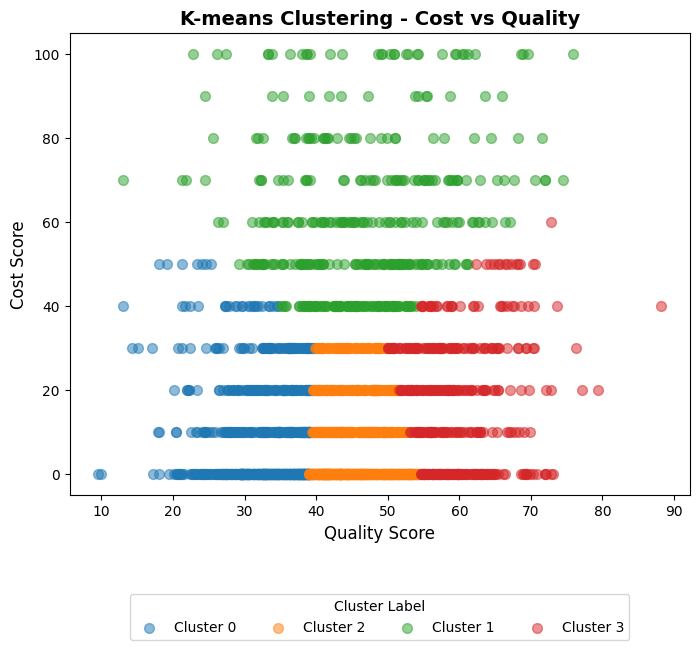

In [7]:
# Get unique cluster labels
unique_labels = raw_df['Cluster_Labels'].unique()

# Plot the clusters
plt.figure(figsize=(8, 6))
for label in unique_labels:
    cluster_data = raw_df[raw_df['Cluster_Labels'] == label]
    plt.scatter(cluster_data['All3Qlty_PersEngage_Safety'], cluster_data['EfficiencyCostReductionScore'], 
                label=f'Cluster {label}', s=50, alpha=0.5)
#plt.scatter(raw_df['All3Qlty_PersEngage_Safety'], raw_df['EfficiencyCostReductionScore'], c=raw_df['Cluster_Labels'], s=50, cmap='viridis', alpha=0.5)

plt.title('K-means Clustering - Cost vs Quality', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Cost Score', fontsize=12)
plt.legend(title='Cluster Label')

# Move legend to the bottom outside of the graph
plt.legend(title='Cluster Label', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=4)

plt.show()

**K-Means with 3 Clusters**

In [8]:
# Scale the data
scaler = StandardScaler()
X = raw_df[['All3Qlty_PersEngage_Safety', 'EfficiencyCostReductionScore']]
X_scaled = scaler.fit_transform(X) # we're not scaling but we should
#X_scaled = X

# Cluster Analysis with k=3
optimal_k = 3

# Create KMeans instance with optimal number of clusters (optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=21)

# Fit KMeans clustering model to the scaled data
kmeans.fit(X_scaled)

# Add a new column to your DataFrame with assigned cluster labels
raw_df['Cluster_Labels_3'] = kmeans.labels_

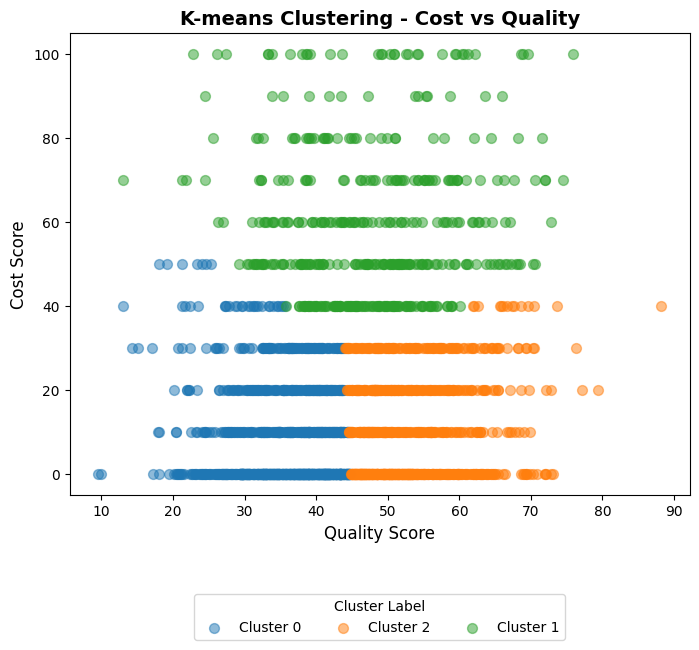

In [9]:
# Get unique cluster labels
unique_labels = raw_df['Cluster_Labels_3'].unique()

# Plot the clusters
plt.figure(figsize=(8, 6))
for label in unique_labels:
    cluster_data = raw_df[raw_df['Cluster_Labels_3'] == label]
    plt.scatter(cluster_data['All3Qlty_PersEngage_Safety'], cluster_data['EfficiencyCostReductionScore'], 
                label=f'Cluster {label}', s=50, alpha=0.5)
#plt.scatter(raw_df['All3Qlty_PersEngage_Safety'], raw_df['EfficiencyCostReductionScore'], c=raw_df['Cluster_Labels'], s=50, cmap='viridis', alpha=0.5)

plt.title('K-means Clustering - Cost vs Quality', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Cost Score', fontsize=12)
plt.legend(title='Cluster Label')

# Move legend to the bottom outside of the graph
plt.legend(title='Cluster Label', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=3)

plt.show()

**3+2 K-Means**

In [10]:
# Filter raw df for cluster label = 1
cluster_1_df = raw_df[raw_df['Cluster_Labels_3']==1]

# Extract features for clustering
X = cluster_1_df[['All3Qlty_PersEngage_Safety']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # we're not scaling but we should
#X_scaled = X

# Cluster Analysis with k=2
optimal_k = 2

# Create KMeans instance with optimal number of clusters (optimal_k)
kmeans = KMeans(n_clusters=optimal_k, random_state=21)

# Fit KMeans clustering model to the scaled data
kmeans.fit(X_scaled)

# Rename clusters to 1a and 1b
cluster_labels_subset = kmeans.labels_
cluster_labels_subset_rename = ['1a' if label == 0 else '1b' for label in cluster_labels_subset]

# Replace initial cluster values with the new labels
raw_df['Cluster_Labels_3_2'] = raw_df['Cluster_Labels_3'].astype('object')
raw_df.loc[raw_df['Cluster_Labels_3_2'] == 1, 'Cluster_Labels_3_2'] = cluster_labels_subset_rename

raw_df

,Facility ID,Facility Name,Address,City,State,Zip Code,County Name,Unweighted Normalized Clinical Care Domain Score,Weighted Normalized Clinical Care Domain Score,Unweighted Person and Community Engagement Domain Score,...,Unweighted Normalized Safety Domain Score,Weighted Safety Domain Score,All3Qlty_PersEngage_Safety,Unweighted Normalized Efficiency and Cost Reduction Domain Score,Weighted Efficiency and Cost Reduction Domain Score,EfficiencyCostReductionScore,Total Performance Score,Cluster_Labels,Cluster_Labels_3,Cluster_Labels_3_2
0,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,Houston,37.500000,9.375000,12,...,40.000000,10.000000,29.8035,0,0.0,0,22.375000,0,0,0
1,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,Marshall,27.500000,6.875000,42,...,21.666667,5.416667,30.3585,0,0.0,0,22.791667,0,0,0
2,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,Lauderdale,27.500000,6.875000,20,...,35.000000,8.750000,27.4725,0,0.0,0,20.625000,0,0,0
3,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,Jefferson,42.500000,10.625000,30,...,33.333333,8.333333,35.2425,0,0.0,0,26.458333,0,0,0
4,10012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DeKalb,16.666667,4.166667,18,...,66.666667,16.666667,33.7440,0,0.0,0,25.333333,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2479,670082,BAYLOR SCOTT AND WHITE MEDICAL CENTER MCKINNEY,5252 WEST UNIVERSITY DRIVE,MC KINNEY,TX,75071,Collin,57.500000,14.375000,39,...,56.666667,14.166667,51.0045,0,0.0,0,38.291667,2,2,2
2480,670085,TEXAS HEALTH HARRIS METHODIST HOSPITAL ALLIANCE,10864 TEXAS HEALTH TRAIL,FORT WORTH,TX,76244,Tarrant,75.000000,18.750000,51,...,30.000000,7.500000,51.9480,0,0.0,0,39.000000,2,2,2
2481,670088,BAYLOR SCOTT & WHITE MEDICAL CENTER- COLLEGE S...,700 SCOTT & WHITE DRIVE,COLLEGE STATION,TX,77845,Brazos,65.000000,16.250000,50,...,55.000000,13.750000,56.6100,10,2.5,10,45.000000,3,2,2
2482,670098,RESOLUTE HEALTH HOSPITAL,"555 CREEKSIDE XING,",NEW BRAUNFELS,TX,78130,Comal,65.000000,16.250000,61,...,60.000000,15.000000,61.9380,0,0.0,0,46.500000,3,2,2


In [11]:
raw_df['Cluster_Labels_3_2'].value_counts()

Cluster_Labels_3_2
0     1179
2      878
1b     216
1a     211
Name: count, dtype: int64

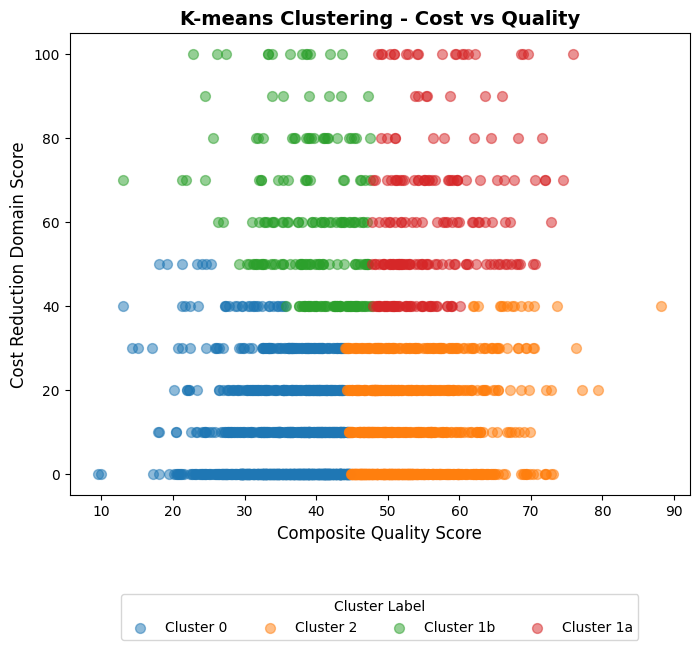

In [12]:
# Get unique cluster labels
unique_labels = raw_df['Cluster_Labels_3_2'].unique()

# Plot the clusters
plt.figure(figsize=(8, 6))
for label in unique_labels:
    cluster_data = raw_df[raw_df['Cluster_Labels_3_2'] == label]
    plt.scatter(cluster_data['All3Qlty_PersEngage_Safety'], cluster_data['EfficiencyCostReductionScore'], 
                label=f'Cluster {label}', s=50, alpha=0.5)
#plt.scatter(raw_df['All3Qlty_PersEngage_Safety'], raw_df['EfficiencyCostReductionScore'], c=raw_df['Cluster_Labels'], s=50, cmap='viridis', alpha=0.5)

plt.title('K-means Clustering - Cost vs Quality', fontsize=14, fontweight='bold')
plt.xlabel('Composite Quality Score', fontsize=12)
plt.ylabel('Cost Reduction Domain Score', fontsize=12)
plt.legend(title='Cluster Label')

# Move legend to the bottom outside of the graph
plt.legend(title='Cluster Label', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=4)

plt.show()

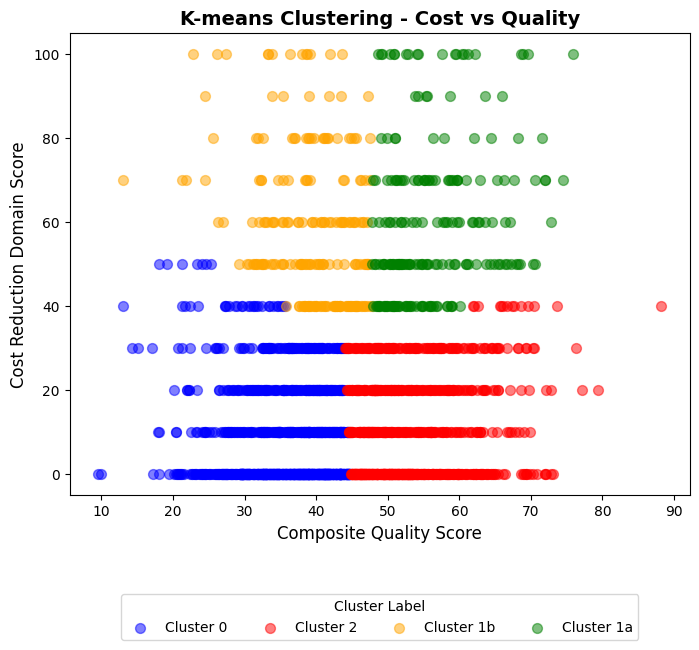

In [18]:
# Define colors for each cluster label
colors = [ 'blue', 'red','orange', 'green']

# Get unique cluster labels
unique_labels = raw_df['Cluster_Labels_3_2'].unique()

# Plot the clusters
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    cluster_data = raw_df[raw_df['Cluster_Labels_3_2'] == label]
    plt.scatter(cluster_data['All3Qlty_PersEngage_Safety'], cluster_data['EfficiencyCostReductionScore'], 
                label=f'Cluster {label}', color=colors[i % len(colors)], s=50, alpha=0.5)

plt.title('K-means Clustering - Cost vs Quality', fontsize=14, fontweight='bold')
plt.xlabel('Composite Quality Score', fontsize=12)
plt.ylabel('Cost Reduction Domain Score', fontsize=12)

# Move legend to the bottom outside of the graph
plt.legend(title='Cluster Label', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=4)

plt.show()